# HIỂN THỊ DANH SÁCH CÁC ẢNH CỦA TẬP DỮ LIỆU

1. Yêu cầu chung: Hiển thị một số ảnh trong bộ dữ liệu theo từng phân loại
  + Ví dụ minh họa:
  <IMG SRC = 'https://editor.analyticsvidhya.com/uploads/762161_OSvbuPLy0PSM2nZ62SbtlQ.png'>
2. Yêu cầu cụ thể:
  - Input: tập tin .csv, trong đó mỗi dòng tương ứng với (đường dẫn) một ảnh và categoryID. Ví dụ tập tin CarDataset-Splits-1-Train.csv
  - Output: như hình minh họa ở trên, mỗi dòng tương ứng với một CategoryID, số lượng ảnh, kích thước ảnh là các tham số với giá trị mặc định như sau
    + NumImgsPerRow = 10
    + ImgHeight = ImgWidth = 150
  - Các ảnh mỗi dòng được chọn ngẫu nhiên ở mỗi lần chạy

3. Nộp bài: SV share notebook. Các bài nộp sớm sẽ được full điểm. Deadline:

4. Bài làm đạt yêu cầu sẽ được paste vào notebook với ghi nhận đóng góp từ tác giả.

## Thông tin của tác giả, ngày cập nhật

# Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import random
import cv2
from google.colab import drive
drive.mount('/content/drive')

# Get Image Path

In [21]:
#dir = "/content/drive/MyDrive/CS114/Competition_1/data"
dir
split = 1
csv_path = f"{dir}/CarDataset-Splits-{split}-Train.csv"
df = pd.read_csv(csv_path, header = None, names=['path', 'ID'])
df = df.iloc[1:]
df.head()

,path,ID
1,Others/22520394-22520395.Others.130.jpg,0
2,Others/22520394-22520395.Others.131.jpg,0
3,Others/22520394-22520395.Others.133.jpg,0
4,Others/22520394-22520395.Others.134.jpg,0
5,Others/22520394-22520395.Others.135.jpg,0


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import random
from PIL import Image

dir = "/content/drive/MyDrive/Public"
num_img = 10
img_height = img_width = 150

def group_img_cate(df):
    grouped = df.groupby('ID')['path'].apply(list).to_dict()
    return grouped

def plot_img(grouped_img, num_img = num_img, img_height = img_height, img_width = img_width):
    categories = list(grouped_img.keys())
    num_categories = len(categories)
    fig, axes = plt.subplots(num_categories, num_img + 1, figsize=(img_width * num_img / 100, img_height * num_categories / 100))
    for i, (category, image_paths) in enumerate(grouped_img.items()):
        selected_images = random.sample(image_paths, min(num_img, len(image_paths)))
        axes[i, 0].text(0.5, 0.5, str(category), va='center', ha='right',
                         transform=axes[i, 0].transAxes, fontsize=12)
        axes[i, 0].axis('off')
        for j, ax in enumerate(axes[i, 1:]):
            ax.axis('off')
            if j < len(selected_images):
                try:
                    selected_images[j] = os.path.join(dir, selected_images[j])
                    img = Image.open(selected_images[j]).resize((img_width, img_height))
                    ax.imshow(img)
                except Exception as e:
                    print(f"Error loading image {selected_images[j]}: {e}")
    plt.suptitle('Train Images',fontsize=20,y=0.92)
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

Error loading image /content/drive/MyDrive/Public/VinFast/22521027-22520195-22521060.VinFast.0918.jpg: [Errno 2] No such file or directory: '/content/drive/MyDrive/Public/VinFast/22521027-22520195-22521060.VinFast.0918.jpg'
Error loading image /content/drive/MyDrive/Public/VinFast/22521425-22520318.VinFast.10.jpg: [Errno 2] No such file or directory: '/content/drive/MyDrive/Public/VinFast/22521425-22520318.VinFast.10.jpg'
Error loading image /content/drive/MyDrive/Public/VinFast/22521027-22520195-22521060.VinFast.0958.jpg: [Errno 2] No such file or directory: '/content/drive/MyDrive/Public/VinFast/22521027-22520195-22521060.VinFast.0958.jpg'
Error loading image /content/drive/MyDrive/Public/VinFast/22521027-22520195-22521060.VinFast.0857.jpg: [Errno 2] No such file or directory: '/content/drive/MyDrive/Public/VinFast/22521027-22520195-22521060.VinFast.0857.jpg'
Error loading image /content/drive/MyDrive/Public/VinFast/22520348-22520530-22520837.VinFast.25.jpg: [Errno 2] No such file or

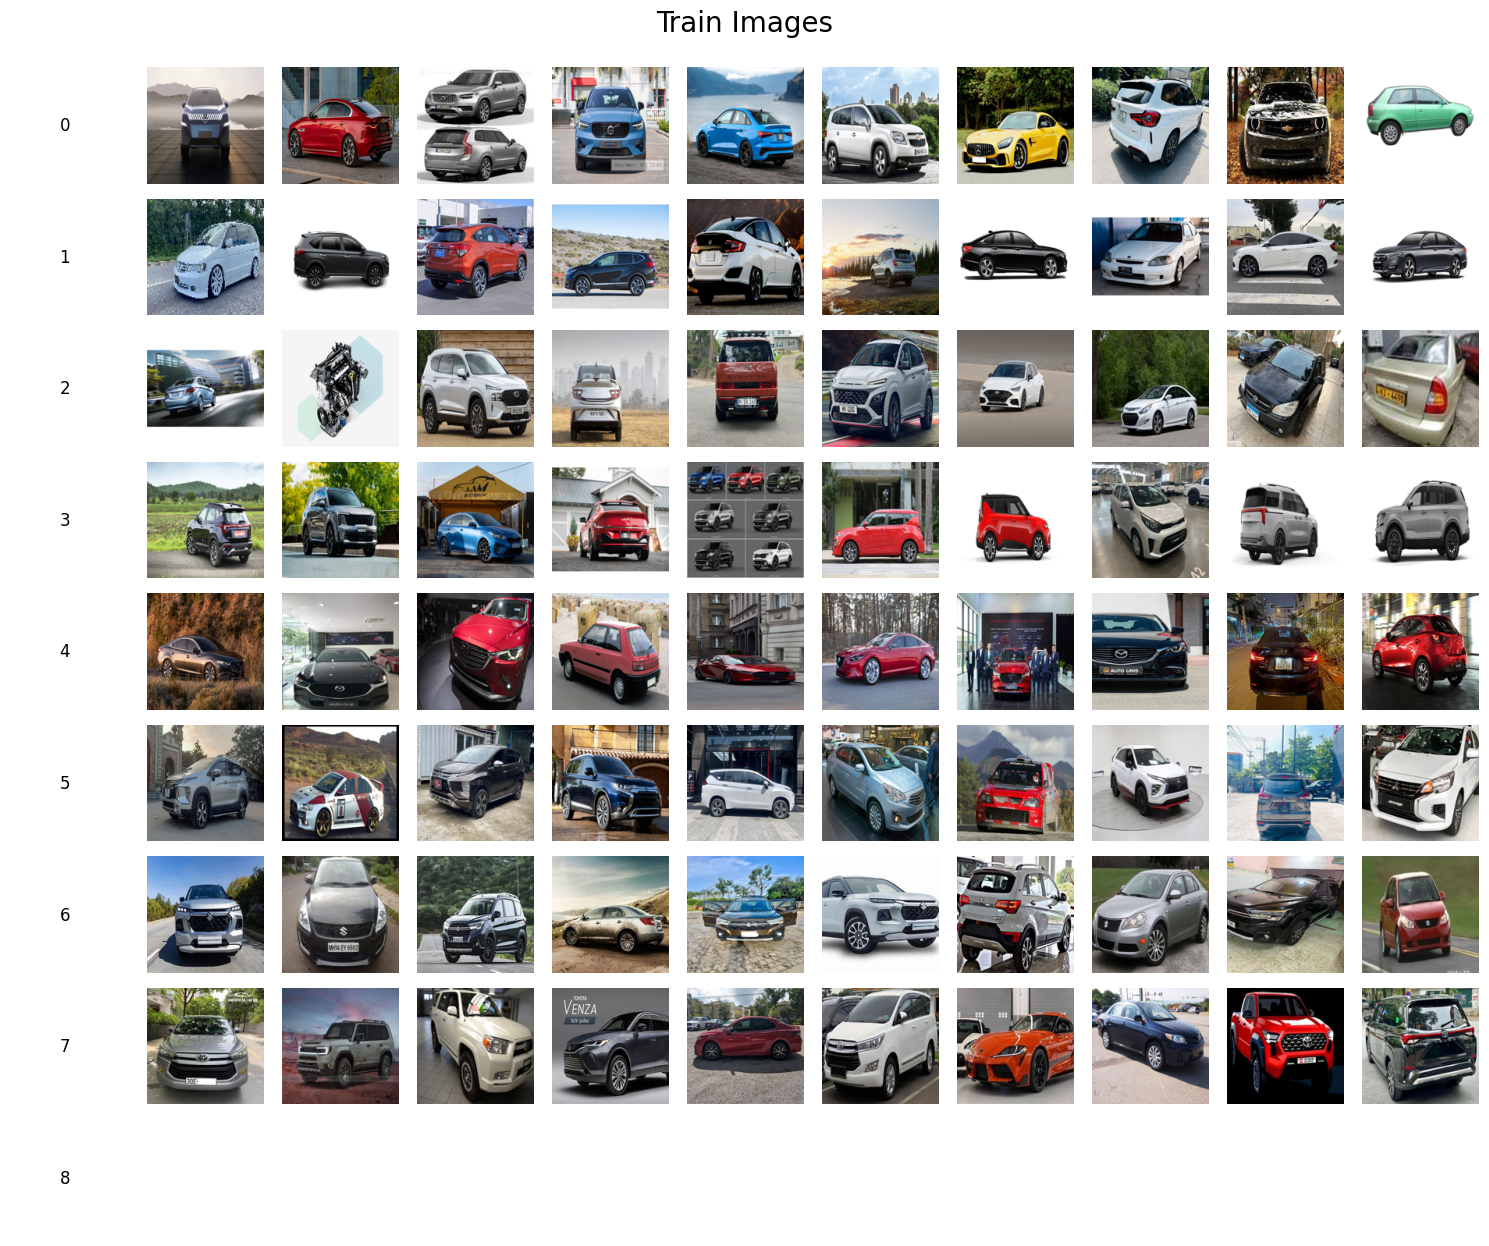

In [24]:
groupdf = group_img_cate(df)
plot_img(groupdf)